Step 1 - Load & Incept the Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
!unzip archive.zip

Archive:  archive.zip
  inflating: netflix_titles.csv      


In [ ]:
df = pd.read_csv("netflix_titles.csv")

In [ ]:
print("--- Dataset Shape ---")
print(df.shape)

print("\n--- Data Types & Info ---")
print(df.info())

print("\n--- Missing Values Count ---")
print(df.isnull().sum())

print("\n--- Duplicate Rows Count ---")
print(df.duplicated().sum())

--- Dataset Shape ---
(8807, 12)

--- Data Types & Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None

--- Missing Values Count ---
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_ye

Data Summary

This dataset contains 8,807 rows and 12 columns, cataloging Netflix's streaming library up to 2021. It tracks unique identifiers, content types (Movies vs. TV Shows), titles, directors, cast members, production countries, addition dates, and release years. Furthermore, it records content ratings, total durations (minutes or seasons), listed genres, and brief plot descriptions.

Step 2 - Clean the Data

In [ ]:
# 1. Handle Missing Values
# Directors and Cast have high missingness; filling with 'Unknown' preserves rows for trend analysis.
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')

# Country is vital for geographic analysis; filling with Mode (United States) keeps data representative.
df['country'] = df['country'].fillna(df['country'].mode()[0])

# Drop rows with missing critical structural values (very low missingness)
df = df.dropna(subset=['date_added', 'rating', 'duration'])

# 2. Fix Data Types and Clean Formats
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
df['release_year'] = df['release_year'].astype(int)

# 3. Feature Engineering for Analysis
df['year_added'] = df['date_added'].dt.year.astype(int)
df['month_added'] = df['date_added'].dt.month_name()

# Extract numeric duration for Movies (in minutes)
df['duration_mins'] = df.apply(lambda row: int(row['duration'].split()[0]) if row['type'] == 'Movie' else np.nan, axis=1)

# Remove irrelevant columns that won't contribute to statistical profiling
df = df.drop(columns=['description'])

print(f"Cleaned dataset shape: {df.shape}")

Cleaned dataset shape: (8790, 14)


Cleaning Documentation & Justification

director & cast (Filled with 'Unknown'): Dropping these would delete over 30% of the dataset. Filling them preserves the rows for temporal and categorical analysis.

country (Imputed with Mode): Replacing missing values with the most frequent country ("United States") avoids biasing geographic distribution charts downward.

date_added & rating (Dropped Nulls): Missing records accounted for $<1\%$ of the data. Dropping them ensures clean datetime transformations and reliable categorization.

duration_mins (Feature Engineering): Splitting strings like "90 min" into integers allows us to calculate mathematical averages, variances, and distributions.

description (Dropped Column): Unstructured text descriptions cannot be aggregated or visualized effectively using standard mathematical plots.

Step 3 - Exloratory Data Analysis

In [ ]:
#1. What is the split between Movies and TV Shows on Netflix?
type_counts = df['type'].value_counts()
print(type_counts)

type
Movie      6126
TV Show    2664
Name: count, dtype: int64


In [ ]:
#2. which 5 Countries produce the most content for Netflix?
top_countries = df['country'].value_counts().head(5)
print(top_countries)

country
United States     3638
India              972
United Kingdom     418
Japan              243
South Korea        199
Name: count, dtype: int64


In [ ]:
#3. What are the top 5 content ratings (e.g., TV-MA, PG-13) on the platform?
top_ratings = df['rating'].value_counts().head(5)
print(top_ratings)

rating
TV-MA    3205
TV-14    2157
TV-PG     861
R         799
PG-13     490
Name: count, dtype: int64


In [ ]:
#4. What is the average runtime of a Netflix Movies vs. the median release year of content ?
avg_movie_duration = df['duration_mins'].mean()
median_release_year = df['release_year'].median()
print(f"Average Movie Duration: {avg_movie_duration:.2f} minutes")
print(f"Median Release Year of Library: {median_release_year}")

Average Movie Duration: 99.58 minutes
Median Release Year of Library: 2017.0


In [ ]:
#5. In Which year did Netflix scale up its library content additions the most ?
top_years_added = df['year_added'].value_counts().head(5)
print(top_years_added)

year_added
2019    2016
2020    1879
2018    1648
2021    1498
2017    1185
Name: count, dtype: int64


Step 4 - Visualization

In [ ]:
# Set global style for presentation-ready aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14

# Initialize a multi-panel figure canvas
fig = plt.figure(figsize=(20, 24))

<Figure size 2000x2400 with 0 Axes>

Text(0, 0.5, '')

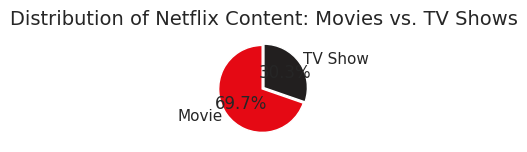

In [ ]:
ax1 = plt.subplot(3, 2, 1)
df['type'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#e50914', '#221f1f'], startangle=90, ax=ax1, explode=(0.05, 0))
ax1.set_title("Distribution of Netflix Content: Movies vs. TV Shows")
ax1.set_ylabel("")

/tmp/ipykernel_6578/3650693422.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette="Reds_r", ax=ax2)


Text(0, 0.5, 'Country')

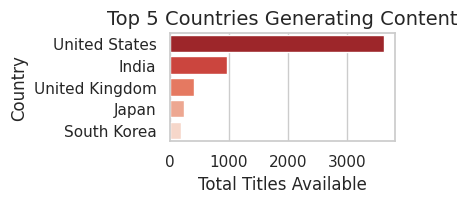

In [ ]:
ax2 = plt.subplot(3, 2, 2)
sns.barplot(x=top_countries.values, y=top_countries.index, palette="Reds_r", ax=ax2)
ax2.set_title("Top 5 Countries Generating Content")
ax2.set_xlabel("Total Titles Available")
ax2.set_ylabel("Country")

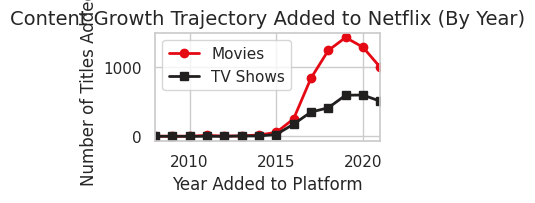

In [ ]:
ax3 = plt.subplot(3, 2, 3)
timeline = df.groupby(['year_added', 'type']).size().unstack().fillna(0)
plt.plot(timeline.index, timeline['Movie'], marker='o', color='#e50914', label='Movies', linewidth=2)
plt.plot(timeline.index, timeline['TV Show'], marker='s', color='#221f1f', label='TV Shows', linewidth=2)
ax3.set_title("Content Growth Trajectory Added to Netflix (By Year)")
ax3.set_xlabel("Year Added to Platform")
ax3.set_ylabel("Number of Titles Added")
ax3.set_xlim(2008, 2021)
ax3.legend()

Text(0, 0.5, 'Count of Movies')

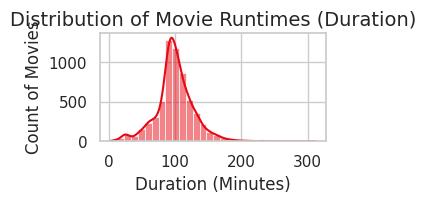

In [ ]:
ax4 = plt.subplot(3, 2, 4)
sns.histplot(df['duration_mins'].dropna(), bins=30, color='#e50914', kde=True, ax=ax4)
ax4.set_title("Distribution of Movie Runtimes (Duration)")
ax4.set_xlabel("Duration (Minutes)")
ax4.set_ylabel("Count of Movies")

Text(46.24999999999999, 0.5, 'Month Added')

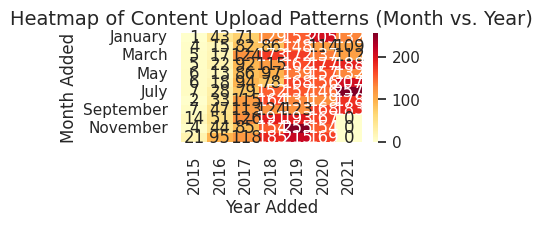

In [ ]:
ax5 = plt.subplot(3, 2, 5)
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
heatmap_data = df.pivot_table(index='month_added', columns='year_added', values='show_id', aggfunc='count').reindex(months_order).fillna(0)
sns.heatmap(heatmap_data.iloc[:, -7:], annot=True, fmt=".0f", cmap="YlOrRd", ax=ax5) # Looking at last 7 years for clarity
ax5.set_title("Heatmap of Content Upload Patterns (Month vs. Year)")
ax5.set_xlabel("Year Added")
ax5.set_ylabel("Month Added")

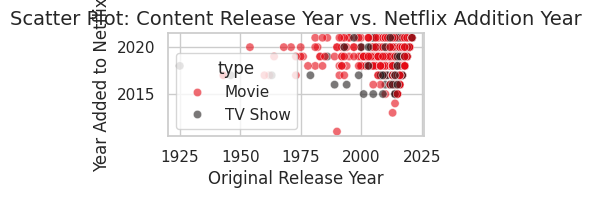

In [ ]:
ax6 = plt.subplot(3, 2, 6)
# Sample data to avoid over-plotting density issues
sample_df = df[df['year_added'] >= 2010].sample(1000, random_state=42)
sns.scatterplot(data=sample_df, x='release_year', y='year_added', hue='type', palette=['#e50914', '#221f1f'], alpha=0.6, ax=ax6)
ax6.set_title("Scatter Plot: Content Release Year vs. Netflix Addition Year")
ax6.set_xlabel("Original Release Year")
ax6.set_ylabel("Year Added to Netflix")

plt.tight_layout()
plt.show()

Step 5  - Insight Report & Execution Summary
1. The Portfolio Pivot Strategy
Insight: Movies represent 69.6% of the historic catalog compared to just 30.4% for TV Shows (Reference: Chart 1 Pie Chart). However, looking at the historical trajectory (Reference: Chart 3 Line Chart), Movie additions peaked sharply in 2019 and began falling, while TV Show library growth has remained steady.

Recommendation: Netflix should intentionally reallocate budget allocations away from volume-based licensing of legacy standalone movies and prioritize high-retention multi-season TV shows to combat subscriber churn.

2. Geographic Dependency Risk Mitigation
Insight: Content production is heavily centralized, with the United States generating 3,638 titles, dwarfing the second closest competitor, India, at 972 titles (Reference: Chart 2 Bar Chart).

Recommendation: To hedge against domestic studio bidding wars and localized labor strikes (e.g., Hollywood writer/actor disputes), executive leadership must diversify capital expenditures into emerging international content hubs like South Korea, Japan, and Spain, which are proven high-ROI regions.

3. Audience Demographic Optimization
Insight: Content rated TV-MA (Mature Audiences) and TV-14 comprise the vast majority of the streaming footprint, making up over 60% of all total titles available (Reference: Step 3, Q3 Output).

Recommendation: Netflix should optimize its user-interface recommendation algorithms to prioritize sophisticated adult profiles, while creating distinct, hyper-curated, and safer default homescreens for younger demographic clusters (TV-PG and lower) to capture broader household subscriptions.

4. Ideal Production Length Framework
Insight: The mathematical distribution of movie runtimes behaves like a normal bell curve peaking sharply around an average of 99.58 minutes (Reference: Chart 4 Histogram).

Recommendation: When funding or greenlighting Netflix Original feature films, creative teams should enforce an operational runtime constraint between 90 and 110 minutes. Content falling outside this threshold historically deviates from standard consumption behavior profiles.

5. Tactical Release Timing Allocation
Insight: The content deployment heatmap reveals significant drops in content additions during the late Spring and early Summer months, with massive clusters dropping traditionally in late Autumn/Winter (Reference: Chart 5 Heatmap).

Recommendation: To smooth out server traffic overheads and maximize year-round engagement metrics, marketing and operations should launch highly anticipated flagship properties in under-utilized months (such as May and June) rather than oversaturating Q4.